In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
import os

# Set your Kaggle API token directly into the environment variables
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_b2a82f39b01eb4f6568fd0afc35b0bc9'

In [4]:
!kaggle datasets list

ref                                                              title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset   FIFA World Cup 2026 Player Performance Dataset        4154062  2026-06-10 12:58:47.093000          20255        500                1  
harshadapatil31/student-performance-and-study-habits-dataset     Student Performance & Study Habits Dataset              15035  2026-07-06 06:28:52.743000           3263         58                1  
abbas829/ecommerce-sales-dataset                                 Ecommerce sales dataset                                110951  2026-07-03 00:59:03.347000           5508         94                1  


In [5]:
!pip install --upgrade kaggle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [6]:
!kaggle datasets download -d niteshyadav3103/concrete-compressive-strength

!unzip concrete-compressive-strength.zip

Dataset URL: https://www.kaggle.com/datasets/niteshyadav3103/concrete-compressive-strength
License(s): CC0-1.0
100% 14.1k/14.1k [00:00<00:00, 23.8MB/s]

Archive:  concrete-compressive-strength.zip
  inflating: Concrete Compressive Strength.csv  


In [7]:
df = pd.read_csv('Concrete Compressive Strength.csv')

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Cement                          1030 non-null   float64
 1   Blast Furnace Slag              1030 non-null   float64
 2   Fly Ash                         1030 non-null   float64
 3   Water                           1030 non-null   float64
 4   Superplasticizer                1030 non-null   float64
 5   Coarse Aggregate                1030 non-null   float64
 6   Fine Aggregate                  1030 non-null   float64
 7   Age (day)                       1030 non-null   int64  
 8   Concrete compressive strength   1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [9]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [10]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age (day),0
Concrete compressive strength,0


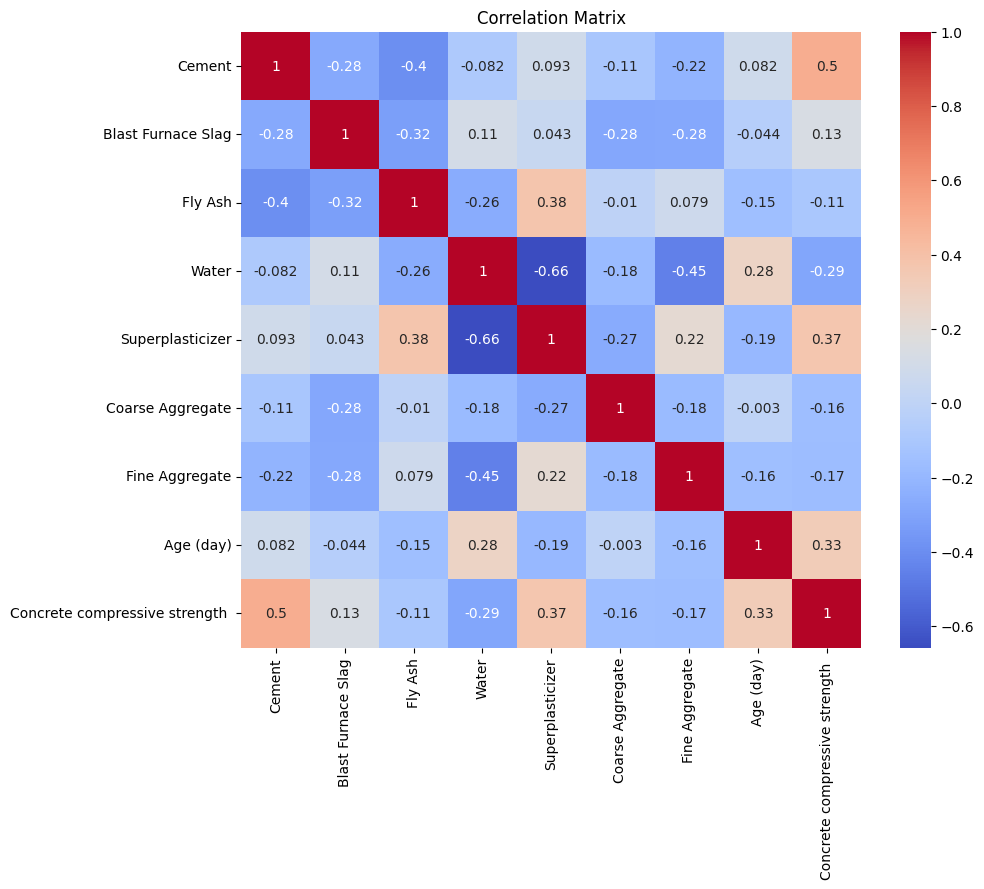

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [12]:
X = df.iloc[:, :-1]

y = df.iloc[:, -1]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
predictions = model.predict(X_test)

In [16]:
r2 = r2_score(y_test, predictions)

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("R² =", r2)
print("MAE =", mae)
print("RMSE =", rmse)

R² = 0.8843319995852106
MAE = 3.7515142259142795
RMSE = 5.459437352345391


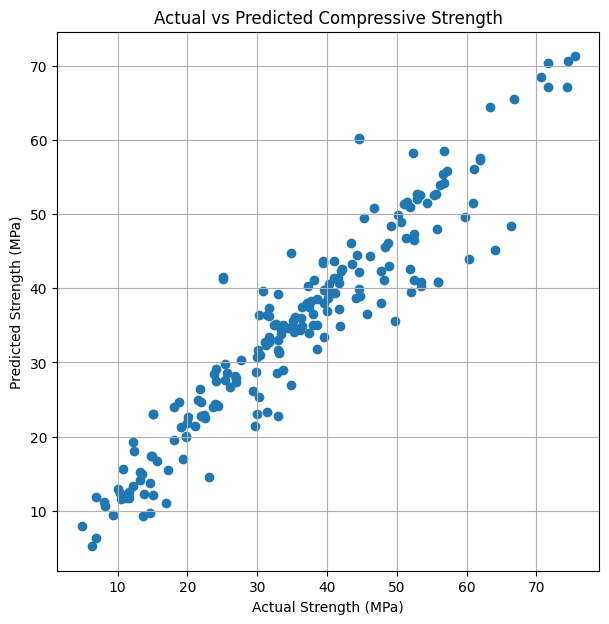

In [17]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Actual vs Predicted Compressive Strength")

plt.grid(True)

plt.show()

In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
7           Age (day)    0.333671
0              Cement    0.323208
3               Water    0.125513
1  Blast Furnace Slag    0.076660
4    Superplasticizer    0.058438
6      Fine Aggregate    0.035100
5    Coarse Aggregate    0.028259
2             Fly Ash    0.019150


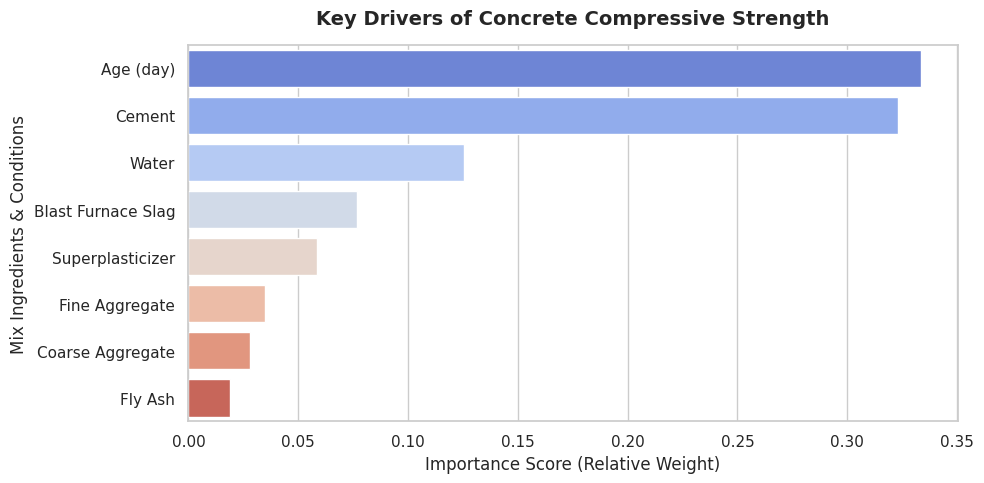

In [23]:
data = {
    'Feature': ['Age (day)', 'Cement', 'Water', 'Blast Furnace Slag', 'Superplasticizer', 'Fine Aggregate', 'Coarse Aggregate', 'Fly Ash'],
    'Importance': [0.333671, 0.323208, 0.125513, 0.076660, 0.058438, 0.035100, 0.028259, 0.019150]
}
importance_df = pd.DataFrame(data)

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='coolwarm', legend=False)

plt.title('Key Drivers of Concrete Compressive Strength', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Relative Weight)', fontsize=12)
plt.ylabel('Mix Ingredients & Conditions', fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
sample_mixes_df = pd.DataFrame(
    [[280.0, 75.0, 50.0, 180.0, 6.0, 970.0, 770.0, 28],
     [400.0, 100.0, 0.0, 150.0, 12.0, 950.0, 750.0, 90]],
    columns=['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
             'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age (day)']
)

predicted_strengths = model.predict(sample_mixes_df)

print("--- Sampled Concrete Strength Predictions ---")
print(f"Sample 1 (Standard 28-Day Mix) Predicted Strength: {predicted_strengths[0]:.2f} MPa")
print(f"Sample 2 (High-Strength 90-Day Mix) Predicted Strength: {predicted_strengths[1]:.2f} MPa")


--- Sampled Concrete Strength Predictions ---
Sample 1 (Standard 28-Day Mix) Predicted Strength: 42.22 MPa
Sample 2 (High-Strength 90-Day Mix) Predicted Strength: 70.19 MPa
